# Explore here

In [29]:
#LIBRERÍAS A UTILIZAR

import pandas as pd


In [30]:
df = pd.read_csv('https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv', sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [31]:
df.shape

(41188, 21)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [33]:
categoricas = df.select_dtypes(include=['str']).columns.tolist() # Esta función sirve para obtener las columnas de algún tipo

categoricas

# Y así obtenemos las que son de tipo 'str'

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

In [34]:
# Y para obtener las numéricas es un proceso casi igual:

numericas = df.select_dtypes(exclude=['str']).columns.tolist()

numericas

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [35]:
# Antes de empezar a tocar estas columnas y empezar a trabajar en ellas, lo primero que tenemos que hacer es ver si hay duplicados:

df.duplicated().sum()

np.int64(12)

In [36]:
# si tenemos filas duplicadas entonces:

if df.duplicated().sum():
    df.drop_duplicates(inplace= True)

df.shape

# Con esto, quitamos las 12 duplicadas.

(41176, 21)

In [37]:
# Vamos a hacer un FOR para transformar variables categóricas en numéricas:

for columna in categoricas:
    df[columna] = pd.factorize(df[columna])[0]

df.info()

# Y todas se transforman en numéricas.

<class 'pandas.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  int64  
 2   marital         41176 non-null  int64  
 3   education       41176 non-null  int64  
 4   default         41176 non-null  int64  
 5   housing         41176 non-null  int64  
 6   loan            41176 non-null  int64  
 7   contact         41176 non-null  int64  
 8   month           41176 non-null  int64  
 9   day_of_week     41176 non-null  int64  
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  int64  
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  float64
 18  eu

In [38]:
df.head()

# El NO quedó como 0, y el SÍ quedó como 1. Tenemos 20 predictoras, es un modelo grande en sí, pero no necesariamente todas las columnas van a servir, y eso lo vemos con un EDA. 

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,0,0,0,0,0,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
1,57,1,0,1,1,0,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
2,37,1,0,1,0,1,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
3,40,2,0,2,0,0,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
4,56,1,0,1,0,0,1,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0


# AQUÍ VA EL EDA (HACERLO SOLITOS)

El fin es crear un algoritmo de clasificación que ayude a **predecir si un cliente contratará o no un depósito a largo plazo**.


### 1) Eliminar información irrelevante:

Debemos responder a la siguiente pregunta: ¿son todas las características imprescindibles para realizar una predicción? Normalmente, esa pregunta es un rotundo no. 

In [39]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,0,0,0,0,0,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
1,57,1,0,1,1,0,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
2,37,1,0,1,0,1,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
3,40,2,0,2,0,0,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
4,56,1,0,1,0,0,1,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0


Considero que todas las variables son dignas de analizarse, porque todas están relacionadas con el problema. No existen índices ni nombres ni ID que no tengan que ver con un préstamos o con el contacto del cliente.

## 2. Eliminamos Duplicados: 
Realizado en un paso anterior.

## 3. Análisis de variables univariante. 

En este caso las variables fueron convertidas todas a numéricas, por ende haremos el anális de tipo numérico. 

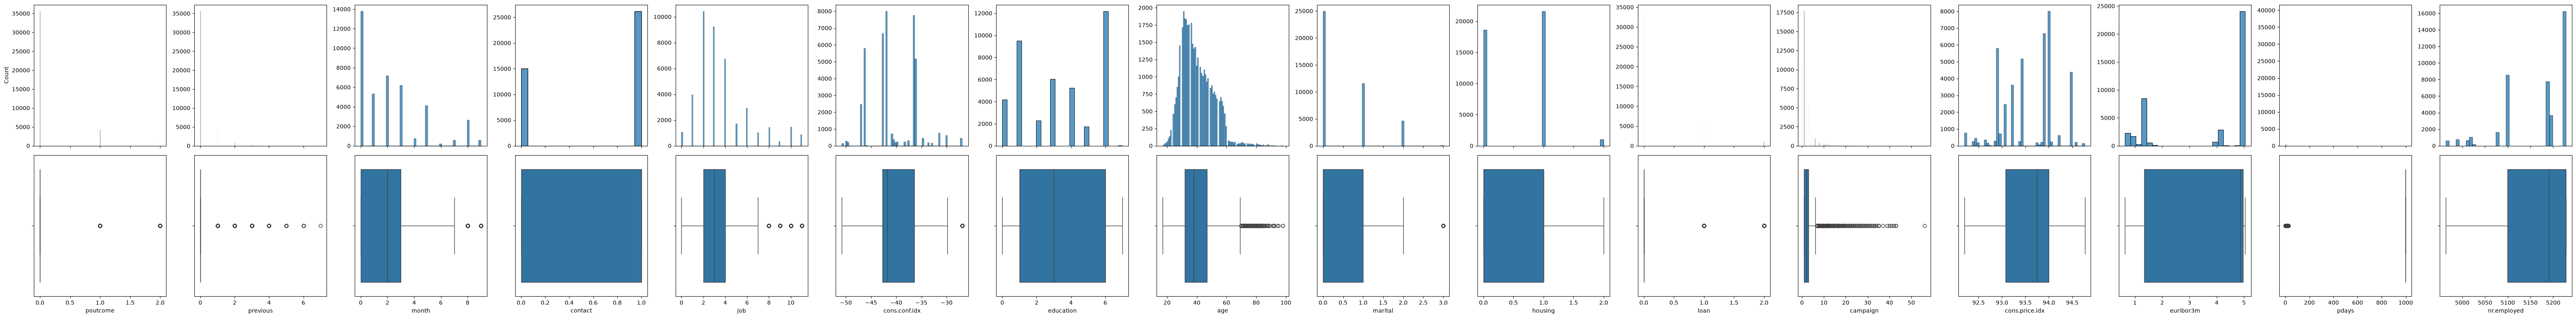

In [40]:
# Ahora vamos a hacer el Análisis sobre variables numéricas


import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definimos la lista limpia con todas las variables numéricas
variables = [
    'poutcome', 'previous', 'month', 'contact', 'job', 
    'cons.conf.idx', 'education', 'age', 'marital', 
    'housing', 'loan', 'campaign', 'cons.price.idx', 
    'euribor3m', 'pdays', 'nr.employed'
]

# 2. Creamos la figura: 2 filas (0: histplot, 1: boxplot) y N columnas (1 por variable)
n_vars = len(variables)
fig, axis = plt.subplots(2, n_vars, figsize=(4 * n_vars, 8), sharex='col')

# 3. Iteramos con un bucle para graficar cada variable en su columna correspondiente
for i, var in enumerate(variables):
    # Fila 0: Histograma
    sns.histplot(ax=axis[0, i], data=df, x=var).set(xlabel=None)
    
    # Quitar etiqueta de Y en los histogramas que no sean el primero para limpiar la vista
    if i > 0:
        axis[0, i].set(ylabel=None)
        
    # Fila 1: Boxplot
    sns.boxplot(ax=axis[1, i], data=df, x=var)

# 4. Ajustar el layout y mostrar
plt.tight_layout()
plt.show()

De la combinación de los dos tipos de gráficos conocemos la distribución y sus características estadísticas, y  de la visualización resultante podemos ver que hay variables como 'poutcome', 'previous', 'loan', 'campaign', 'pdays' que deberíamos descartarlas por la falta de valores/información que éstas nos proveen. 

También podemos identificar que el mayor número de contactos se realizaron en el mes de Enero, 

1. Variables con Sesgo Fuerte y Distribución Asimétrica - pdays (Días desde el último contacto de una campaña previa): La inmensa mayoría de los valores se concentran en $999$ (que indica que el cliente no fue contactado previamente). Conclusión: Es una variable con muy varianza real útil en su forma continua; sería mucho más efectivo transformarla en una variable binaria/categórica (ej. contactado_previamente: 0 ó 1).previous y campaign: Muestran un sesgo positivo muy pronunciado hacia el $0$ o valores bajos ($1$-$2$). La mayoría de los clientes reciben muy pocos contactos en la campaña actual o no tienen contactos previos.

2. Presencia de Valientes Desviados (Outliers)campaign y age: Los gráficos de caja (boxplots) muestran bastantes puntos fuera de los bigotes superiores. En campaign, hay llamadas repetidas a un mismo cliente que se salen completamente del comportamiento normal.Atención para el modelo: La Regresión Logística es sensible a valores extremadamente alejados o escalados, por lo que estas variables se beneficiarán mucho de un escalado (como StandardScaler o RobustScaler) o de un tratamiento de outliers.

3. Discrepancia sobre el descarte de variables (Ojo con poutcome)En tu texto mencionas la idea de descartar poutcome o pdays, pero cuidado:Aunque poutcome o previous tengan muchos ceros/valores constantes, el historial de campañas previas suele ser uno de los predictores más potentes del éxito ($y$).Recomendación: En lugar de eliminarlas por "falta de datos", conviene reformularlas o combinarlas. Por ejemplo, poutcome cuando es "success" tiene un impacto altísimo en la tasa de conversión.

4. Estructura de las Variables Macroeconómicas y TemporalesVariables como nr.employed, euribor3m y emp.var.rate no siguen una distribución normal; muestran picos y niveles muy definidos correspondientes a diferentes momentos o trimestres económicos.

## 4. Análisis de variables multivariante. Análisis numérico-numérico.
Tras analizar las características una a una, es momento de analizarlas en relación con la predictora y con ellas mismas, para sacar conclusiones más claras acerca de sus relaciones y poder tomar decisiones sobre su procesamiento.

Para comparar dos columnas numéricas se utilizan diagramas de dispersión y análisis de correlaciones.

Pero antes vamos a realizar una Matríz de correlación, ya que esta es una tabla que muestra los coeficientes de correlación entre varias variables numéricas al mismo tiempo. 
Cada celda de la tabla te indica qué tan fuertemente se relacionan dos variables entre sí:

1.0: Correlación positiva perfecta (si una sube, la otra también sube en la misma proporción).

0.0: Sin relación lineal.

-1.0: Correlación negativa perfecta (si una sube, la otra baja).

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. MATRIZ DE CORRELACIÓN
# ---------------------------------------------------------
# Calculamos la correlación de Pearson
corr_matrix = df.corr()

# Si querés ver solo las variables con mayor correlación con el TARGET ('y')
print("--- Correlación de cada variable con el Target 'y' ---")
print(corr_matrix['y'].sort_values(ascending=False))

--- Correlación de cada variable con el Target 'y' ---
y                 1.000000
duration          0.405297
poutcome          0.270399
previous          0.230202
month             0.183541
contact           0.144774
job               0.054829
cons.conf.idx     0.054802
education         0.045663
age               0.030381
marital           0.026363
day_of_week       0.009993
housing           0.009605
loan             -0.005051
campaign         -0.066361
default          -0.099364
cons.price.idx   -0.136134
emp.var.rate     -0.298289
euribor3m        -0.307740
pdays            -0.324948
nr.employed      -0.354669
Name: y, dtype: float64


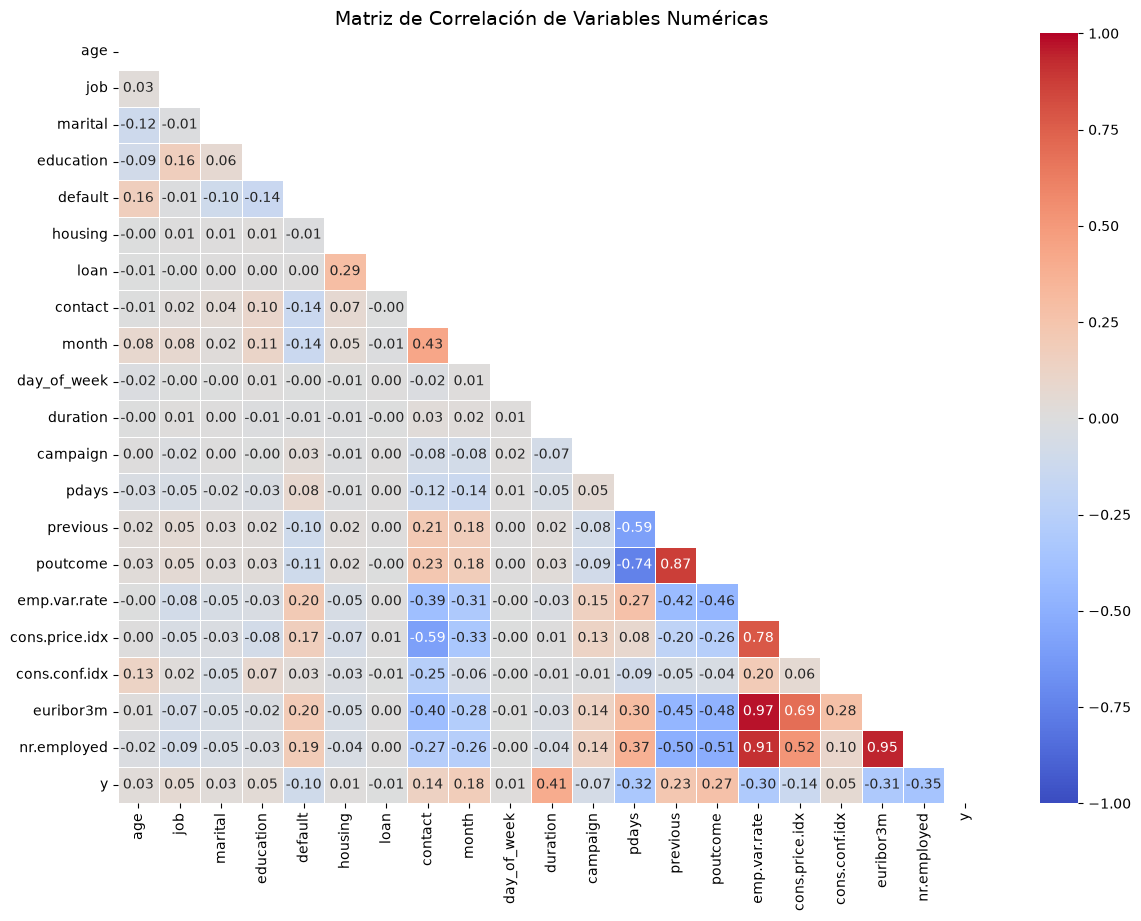

In [42]:
# 2. MAPA DE CALOR (HEATMAP)
# ---------------------------------------------------------
plt.figure(figsize=(14, 10))

# Mascará para mostrar solo la mitad inferior (evita duplicados visuales)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,          # Muestra el número dentro de cada celda
    fmt=".2f",           # Redondea a 2 decimales
    cmap='coolwarm',     # Rojo = pos, Azul = neg
    vmin=-1, vmax=1,     # Escala fija de -1 a 1
    linewidths=0.5
)

plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14)
plt.show()

De este gráfico de mapa de calor podemos visualizar la correlación existente o no entre las variables:

1. Redundancia Severa (Multicolinealidad Extrema)
Hay tres bloques de variables que están tan fuertemente correlacionadas entre sí que aportan la misma información. Mantenerlas todas distorsiona modelos lineales (como Regresión Logística) y genera sobreajuste:

El bloque de indicadores macroeconómicos:

- euribor3m vs emp.var.rate: 0.97 (Correlación casi perfecta).

- euribor3m vs nr.employed: 0.95.

- emp.var.rate vs nr.employed: 0.91.

- emp.var.rate vs cons.price.idx: 0.78.

Recomendación: Elegir solo 1 de estas para el modelo final (por ejemplo, euribor3m o emp.var.rate) y descartar las demás para limpiar el espacio de variables.

Historial de campañas anteriores:

- poutcome vs previous: 0.87 (Casi redundantes).

- poutcome vs pdays: -0.74 (Correlación negativa fuerte).

- pdays vs previous: -0.59.

Recomendación: Tienen un sentido lógico clarísimo (si hubo campaña previa exitosa, hay menos días transcurridos y más contactos previos). poutcome y pdays son muy valiosas, pero evalúa si conservar las tres o combinar pdays en un indicador binario.

2. ¿Qué variables se relacionan mejor con el TARGET (y)?
Mirando la última fila de la matriz, las variables con mayor poder predictivo lineal son:

Las que más aumentan la probabilidad de éxito (y):

- poutcome (0.27) y previous (0.23): Confirmado, el historial exitoso del cliente es el mejor predictor positivo.

- month (0.18) y contact (0.14): La época del año y el medio de contacto tienen cierto impacto positivo.

Las que más REDUCEN la probabilidad de éxito (y):

- nr.employed (-0.35), pdays (-0.32), euribor3m (-0.31) y emp.var.rate (-0.30): A mayor tasa de interés (Euribor) o peor situación de empleo, menor predisposición del cliente a dejar su dinero retenido en un depósito a largo plazo.

3. Variables "Muertas" o irrelevantes (Prácticamente sin correlación)
- Variables demográficas directas como age (0.03), marital (0.03), housing (0.01) y loan (-0.01) muestran correlaciones lineales casi nulas con y.

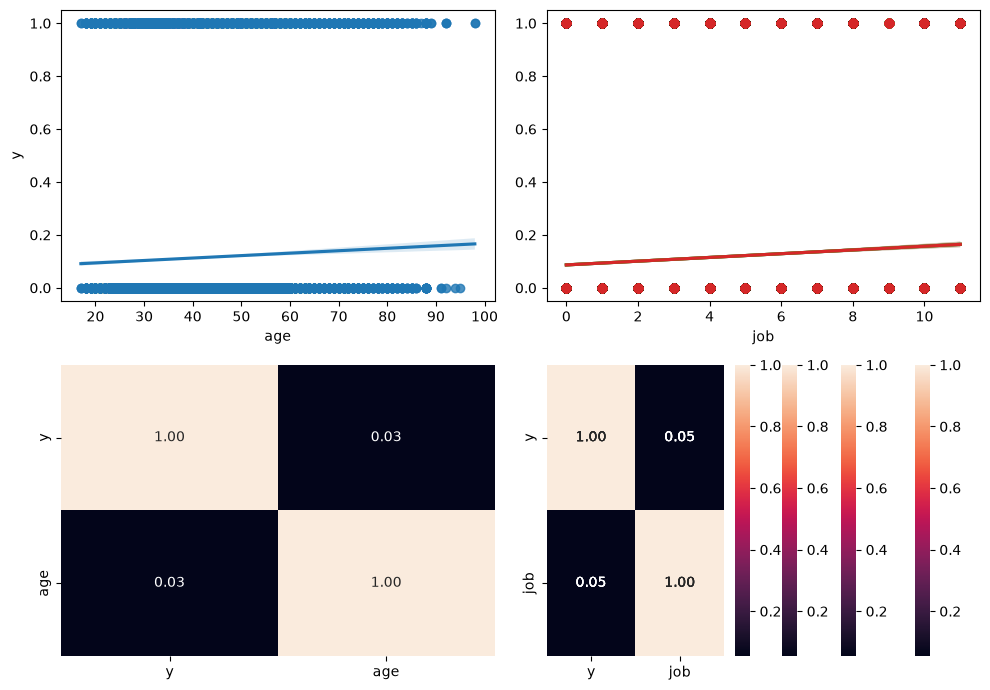

In [43]:
fig, axis = plt.subplots(2, 2, figsize = (10, 7))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = df, x = 'age', y = "y")
sns.heatmap(df[["y", 'age']].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = df, x = 'job', y = "y").set(ylabel=None)
sns.heatmap(df[["y", 'job']].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])
sns.regplot(ax = axis[0, 1], data = df, x = 'job', y = "y").set(ylabel=None)
sns.heatmap(df[["y", 'job']].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])
sns.regplot(ax = axis[0, 1], data = df, x = 'job', y = "y").set(ylabel=None)
sns.heatmap(df[["y", 'job']].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])
sns.regplot(ax = axis[0, 1], data = df, x = 'job', y = "y").set(ylabel=None)
sns.heatmap(df[["y", 'job']].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

In [44]:
# Antes del modelo, tengo que definir mis x de train y de test:

x = df.drop(columns=['y'])
y= df['y']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 )

In [45]:
# Tenemos que hacer la normalización de los datos (chequear si usamos el "standar" si sé que mis datos distribuyen normal, si no lo sé, voy a usar minmax) Asique en este caso lo vamos a hacer con minmax porque todavía no hacemos el Eda y estamos como ciegos. Luego que de que hagan el EDa pueden tomar una mejor decisión.

from sklearn.preprocessing import MinMaxScaler

scaler= MinMaxScaler()

x_train_esc = scaler.fit_transform(x_train)

x_train_esc = pd.DataFrame(x_train_esc, columns= x_train.columns, index= x_train.index)

x_test_esc = scaler.transform(x_test)

x_test_esc = pd.DataFrame(x_test_esc, columns =x_test.columns, index= x_test.index)




In [46]:
x_train_esc.head() # para que los podamos ver. Y ahí ya están escalados los datos.

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
12348,0.148148,0.909091,0.000000,0.285714,0.0,0.5,0.5,0.0,0.222222,1.00,0.058154,0.036364,1.0,0.0,0.0,1.000000,0.669135,0.338912,0.980503,1.000000
8565,0.407407,0.181818,0.333333,0.857143,0.0,0.0,0.0,0.0,0.111111,0.50,0.036194,0.090909,1.0,0.0,0.0,1.000000,0.882307,0.376569,0.958966,1.000000
21424,0.148148,0.181818,0.333333,0.857143,0.0,0.0,0.0,1.0,0.333333,0.25,0.020943,0.054545,1.0,0.0,0.0,1.000000,0.484412,0.615063,0.981410,1.000000
3316,0.222222,0.181818,0.333333,0.857143,0.0,0.0,0.0,0.0,0.000000,0.75,0.027450,0.000000,1.0,0.0,0.0,0.937500,0.698753,0.602510,0.958059,0.859735
33246,0.283951,0.272727,0.333333,0.142857,0.5,0.0,0.0,1.0,0.000000,0.25,0.084994,0.000000,1.0,0.0,0.0,0.333333,0.269680,0.192469,0.148946,0.512287


In [47]:
# Una vez que todas las columnas son numéricas y están escaladas, podemos pensar en hacer una REGRESIÓN LOGÍSTICA:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train_esc, y_train)

# Y tenemos todos los hiperparámetros que está utilizando el modelo por defecto. Y tmb podemos ver los atributos del modelo, que es lo que usó para hacer las predicciones.

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [48]:
# Hasta acá ya tengo un modelo entrenado sobre mis x de entrenamiento (x_train). 
# Ahora lo que necesito son resultados. 

y_pred = model.predict(x_test_esc)
y_pred

# ¿Cómo se va an a ver? En este caso es un Array de 8.236 de largo, que es el 20% + o - de los 41 mil casos que tengo, y voy a ver un conjunto de unos y ceros. Esto sólo me dice que ya el modelo hizo predicciones. 

array([1, 0, 0, ..., 0, 0, 0], shape=(8236,))

In [49]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

# Acá comparamos los y de test con los y predichos. 
# y nos dice que este modelo (sin el EDA realizado todavía) tiene un 90.23 % de probabilidad de acertar. Si yo ahora analizo un nuevo cliente, mi modelo va a ser capaz de predecir en un 90% si ese cliente va a tomar o no va a tomar un crédito. 

0.9023797960174842

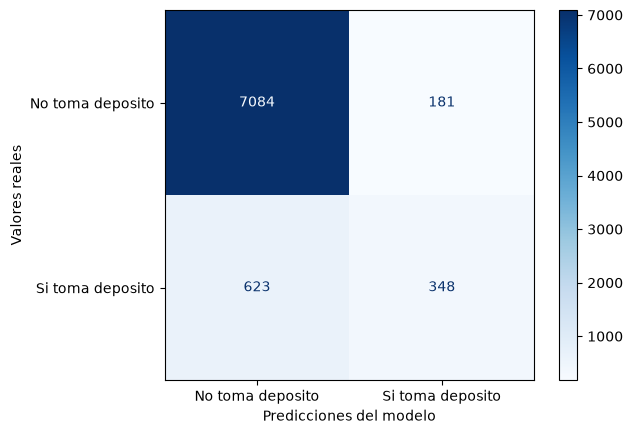

In [50]:
# Matríz de confusión

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp= ConfusionMatrixDisplay (cm, display_labels=['No toma deposito', 'Si toma deposito'])

disp.plot(cmap=plt.cm.Blues)

plt.xlabel('Predicciones del modelo')
plt.ylabel('Valores reales')
plt.show()


# En el EDA tenemos que mejorar todavía más el modelo.

In [51]:
# Una vez que ya tengo el modelo base, ya podemos hacer la búsqueda de hiperparámetros

from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid = {
    'penalty' : ['l1', 'l2', 'elasticnet', None],
    'C': [0.001, 0.01, 0.1, 10.0, 100.0, 1000.0],
    'solver': ['saga'],
    'l1_ratio': [0.5],
    'max_iter': [2000]
}

grid_search = GridSearchCV (
    estimator = model,
    param_grid= param_grid,
    cv = 5,
    scoring ='accuracy',
    n_jobs= -1
)


In [52]:
# Ahí está definida la grilla, ahora hay que entrenarla

grid_search.fit(x_train_esc, y_train)


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1421: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.5. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'pe

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'l1_ratio': [0.5], 'max_iter': [2000], 'penalty': ['l1', 'l2', ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Con

In [53]:
print(grid_search.best_params_)

{'C': 0.001, 'l1_ratio': 0.5, 'max_iter': 2000, 'penalty': None, 'solver': 'saga'}


In [54]:
mejor_modelo = grid_search.best_estimator_

y_pred_mejor = mejor_modelo.predict(x_test_esc)
accuracy_score(y_test, y_pred_mejor)

# No es una gran mejora la que obtuvimos, pero mejoró a 90.38 %. 

0.9038368139873725